<a href="https://colab.research.google.com/github/thadduslee/Orbital-2026/blob/main/Base_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade torchao peft transformers
!pip install --upgrade --force-reinstall transformers tokenizers sentencepiece


In [59]:
import tensorflow as tf
import pandas as pd
import numpy as np

### **Use previously trained huggingface model**

In [60]:
from transformers import AutoModelForSequenceClassification, DebertaV2Tokenizer, pipeline

model_id = "thaddus/deberta-lora-module-scorer"
print(f"Loading Hugging Face model: {model_id}...")


config = PeftConfig.from_pretrained(peft_model_id)
base_model_name = config.base_model_name_or_path

tokenizer = AutoTokenizer.from_pretrained(base_model_name)


base_model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=1,
    ignore_mismatched_sizes=True
)

model = PeftModel.from_pretrained(base_model, peft_model_id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


print("Model loaded successfully!")

Loading Hugging Face model: thaddus/deberta-lora-module-scorer...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.den

Model loaded successfully!


## **Step 1: Fetch ALL NUSMods data from Disqus (run once per session)**

This cell makes two API calls (threads + posts) and caches everything to disk.
Once it finishes, all later cells work purely from the in-memory `df_reviews` DataFrame.


In [5]:
import requests, json, csv, time, os, re
from bs4 import BeautifulSoup
import pandas as pd

def _get_api_key():
    try:
        from google.colab import userdata
        key = userdata.get("DISQUS_API_KEY")
        if key:
            print("API key loaded from Colab Secrets.")
            return key
    except Exception:
        pass
    key = os.environ.get("DISQUS_API_KEY", "")
    if key:
        print("API key loaded from environment variable.")
        return key
    raise RuntimeError(
        "No API key found.\n"
        "  In Colab: Secrets -> add DISQUS_API_KEY -> enable notebook access.\n"
        "  Make sure you copy the PUBLIC KEY from your Disqus app, not the Secret Key."
    )

DISQUS_API_KEY = _get_api_key()
FORUM_NAME     = "nusmods-prod"   #Disqus shortname for NUSMods
LIMIT          = 100         #Disqus max per request
DELAY          = 1.0         #Seconds between pages
JSON_OUT       = "nusmods_reviews.json"
CSV_OUT        = "nusmods_reviews.csv"
CHECKPOINT     = "nusmods_posts_checkpoint.json"


def verify_forum():
    resp = requests.get(
        "https://disqus.com/api/3.0/forums/details.json",
        params={"api_key": DISQUS_API_KEY, "forum": FORUM_NAME},
        timeout=15
    )
    data = resp.json()
    code = data.get("code", -1)

    #disqus error codes: 2=missing key, 5=invalid key, 18=bad forum
    if code == 2 or code == 5:
        raise RuntimeError(
            f"\nAPI key rejected (Disqus code {code}).\n"
            "  Go to https://disqus.com/api/applications/ -> your app\n"
            "  Copy the PUBLIC KEY (not Secret Key) and update your Colab Secret."
        )
    if code == 18:
        raise RuntimeError(
            f"\nForum not found (Disqus code {code}).\n"
            "  Check the shortname: open nusmods.com, right-click -> View Page Source,\n"
            "  search for 'disqus_shortname' to find the correct value."
        )
    if code != 0:
        raise RuntimeError(f"Disqus error {code}: {data.get('response', data)}")

    info = data["response"]
    print(f"Forum verified: '{info['name']}' | shortname='{info['id']}' | posts={info.get('posts','?')}")
    return info


def fetch_all(endpoint, label, extra=None):
    """
    Downloads every page from a Disqus list endpoint.
    Returns a flat list of all items.
    """
    url   = f"https://disqus.com/api/3.0/{endpoint}"
    items = []
    cursor = None
    page   = 0

    print(f"\n  Fetching {label}...")

    while True:
        params = {
            "api_key": DISQUS_API_KEY,
            "forum":   FORUM_NAME,
            "limit":   LIMIT,
            "order":   "asc",
        }
        if extra:
            params.update(extra)
        if cursor:
            params["cursor"] = cursor

        #Retry up to 5× on network errors or 429s
        for attempt in range(5):
            try:
                resp = requests.get(url, params=params, timeout=30)
            except requests.RequestException as e:
                wait = 2 ** attempt
                print(f"Network error (attempt {attempt+1}): {e}. Retrying in {wait}s...")
                time.sleep(wait)
                continue

            if resp.status_code == 429:
                wait = int(resp.headers.get("Retry-After", 30))
                print(f"Rate limited. Waiting {wait}s...")
                time.sleep(wait)
                continue

            if resp.status_code != 200:
                raise RuntimeError(f"HTTP {resp.status_code}: {resp.text[:300]}")

            break
        else:
            raise RuntimeError("Max retries exceeded, aborting.")

        body = resp.json()

        #Disqus surfaces API-level errors even on HTTP 200
        if body.get("code", 0) != 0:
            raise RuntimeError(f"Disqus error {body['code']}: {body.get('response')}")

        batch = body.get("response", [])
        items.extend(batch)
        page += 1
        print(f"Page {page:>4}: +{len(batch):>4}: total {len(items):>6}", end="\r")

        cursor_data = body.get("cursor", {})
        if cursor_data.get("hasNext"):
            cursor = cursor_data["next"]
            time.sleep(DELAY)
        else:
            print(f" {label}: {len(items)} items fetched across {page} pages.")
            break

    return items


#clean HTML comment text
def clean_html(html_text):
    if not html_text:
        return ""
    text = BeautifulSoup(html_text, "html.parser").get_text(separator=" ")
    text = re.sub(r"Module review by.*?:", "", text)
    text = re.sub(r"Taken in AY\d+/\d+ Sem \d+", "", text)
    text = re.sub(r"Module review also posted here:.*", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def module_code_from_title(title):
    if not title:
        return "UNKNOWN"
    first = title.strip().split()[0]
    return first if re.match(r"^[A-Z]{2,4}\d{4}[A-Z]?$", first) else "UNKNOWN"


print("=" * 60)
print("NUSMods Disqus Scraper")
print("=" * 60)

verify_forum()

threads = fetch_all("forums/listThreads.json", "threads")

thread_map = {}
for t in threads:
    thread_map[t["id"]] = {
        "module_code":  module_code_from_title(t.get("title", "")),
        "module_title": t.get("title", "Unknown"),
        "module_link":  t.get("link", ""),
    }

known = sum(1 for v in thread_map.values() if v["module_code"] != "UNKNOWN")
print(f"  Thread map: {len(thread_map)} threads, {known} with valid module codes.")

raw_posts = fetch_all(
    "forums/listPosts.json",
    "posts",
    extra={"include": "approved"},
)

with open(CHECKPOINT, "w", encoding="utf-8") as f:
    json.dump(raw_posts, f)
print(f"Checkpoint saved -> {CHECKPOINT}")

records = []
for post in raw_posts:
    tid  = post.get("thread")
    info = thread_map.get(tid, {"module_code": "UNKNOWN",
                                "module_title": "Unknown",
                                "module_link":  ""})
    raw_msg = post.get("message", "") or ""
    records.append({
        "comment_id":       post.get("id"),
        "thread_id":        tid,
        "module_code":      info["module_code"],
        "module_title":     info["module_title"],
        "module_link":      info["module_link"],
        "author_name":      post.get("author", {}).get("name", "Anonymous"),
        "date":             post.get("createdAt"),
        "raw_message":      raw_msg,            #original HTML
        "message":          clean_html(raw_msg), #plain text
        "likes":            post.get("likes", 0),
        "dislikes":         post.get("dislikes", 0),
        "parent_comment_id": post.get("parent"),
    })


with open(JSON_OUT, "w", encoding="utf-8") as f:
    json.dump(records, f, indent=2, ensure_ascii=False)

if records:
    with open(CSV_OUT, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=records[0].keys())
        writer.writeheader()
        writer.writerows(records)

#load into pandas dataframe (easier manipulation)
df_reviews = pd.DataFrame(records)
df_reviews = df_reviews[
    (df_reviews["module_code"] != "UNKNOWN") &
    (df_reviews["message"].str.strip() != "")
].reset_index(drop=True)

print("\n" + "=" * 60)
print(f" Done. {len(df_reviews)} usable reviews across "
      f"{df_reviews['module_code'].nunique()} modules.")
print(f"Saved -> {JSON_OUT} | {CSV_OUT}")
print("=" * 60)
df_reviews[["module_code", "module_title", "date", "message"]].head(5)


API key loaded from Colab Secrets.
NUSMods Disqus Scraper
Forum verified: 'NUSMods' | shortname='nusmods-prod' | posts=?

  Fetching threads...
 threads: 21020 items fetched across 211 pages.
  Thread map: 21020 threads, 19335 with valid module codes.

  Fetching posts...
 posts: 9681 items fetched across 97 pages.
Checkpoint saved -> nusmods_posts_checkpoint.json

 Done. 9591 usable reviews across 2073 modules.
Saved -> nusmods_reviews.json | nusmods_reviews.csv


,module_code,module_title,date,message
0,CS3216,CS3216 Software Development on Evolving Platforms,2014-06-29T23:43:01,Awesomeness!
1,CS1020E,CS1020E Data Structures and Algorithms I,2014-07-06T17:08:51,This looks interesting :). Anybody has any tip...
2,CS1020E,CS1020E Data Structures and Algorithms I,2014-07-06T19:07:57,"Hey Bhavesh, sure thing, you can find more inf..."
3,ACC1002X,ACC1002X Financial Accounting,2014-07-06T20:20:30,Definitely a course to take for people who wan...
4,CS3216,CS3216 Software Development on Evolving Platforms,2014-07-07T10:04:11,For those who are thinking of taking CS3216 in...


## **Step 2: Enter a module to analyse**

Filter from the already-loaded `df_reviews` DataFrame. No more file reads.


In [61]:
#show all available modules so the user knows what to type
available = sorted(df_reviews["module_code"].unique())
print(f"{len(available)} modules with reviews:")
print(", ".join(available))


2073 modules with reviews:
ACC1002, ACC1002X, ACC1006, ACC1701, ACC1701X, ACC2002, ACC2706, ACC2707, ACC2708, ACC2709, ACC3701, ACC3703, ACC3707, AH2101, AH2201, AH2202, AH2204, AH3203, AH3550, ALS1010, AN1101E, AN2101, AN2203, AN2205, AN3101, AR1101, BI3708A, BL5198, BL5217, BL5601, BL5602, BMA5334A, BMA5515, BMD5301, BMD5302, BMH5105, BMH5303, BMI5101, BMI5106, BMI5111, BMI5201, BMI5207, BMI5306, BMS5211, BN1112, BN2102, BN2201, BN2202, BN2204, BN2401, BN2403, BN4102, BN4301, BN4403, BN5101, BN5104, BN5210, BN6401, BPS5229, BSE3711, BSN3701, BSN3714, BSN4811, BSN4811A, BSP1004, BSP1005, BSP1702, BSP1703, BSP1707A, BSP2005, BSP3701A, BSP3701C, BT1101, BT2101, BT2102, BT2103, BT3017, BT3102, BT3103, BT4012, BT4013, BT4014, BT4016, BT4103, BT4211, BT4212, BT4221, BT4222, BT4240, BT4301, BT5153, CDE2000, CDE2001, CDE2212, CDE2310, CDE2501, CDE2502, CDE3504, CE1101, CE1103, CE2112T, CE2134, CE2155, CE2184, CE2407A, CE2407B, CE3115, CE3116, CE3121, CE3132, CE3155A, CE3155B, CE3165, CE3166,

### **Receive user input for module to conduct sentiment analysis on**

In [76]:
module = input("Enter module code (e.g. CS1010A): ").upper().strip()
subset = df_reviews[df_reviews["module_code"] == module]

if subset.empty:
    print(f"No reviews found for '{module}'.")
    close = [m for m in df_reviews['module_code'].unique() if m.startswith(module[:2])]
    if close:
        print(f"   Did you mean one of: {sorted(close)[:10]}?")
else:
    messages = subset["message"].tolist()
    print(f"Found {len(messages)} reviews for {module}.")


Enter module code (e.g. CS1010A): ma1521
Found 102 reviews for MA1521.


### Helper function to clean **comments**

In [77]:
from bs4 import BeautifulSoup
import re

def clean_review_text(html_text):
    #parse HTML and separate tags with a space
    soup = BeautifulSoup(html_text, "html.parser")
    text = soup.get_text(separator=' ')

    #remove noise
    #remove "Module review by..." at the start
    text = re.sub(r'Module review by.*?:', '', text)
    #remove "Taken in AY..."
    text = re.sub(r'Taken in AY\d+/\d+ Sem \d+', '', text)
    #remove "Module review also posted here" footer
    text = re.sub(r'Module review also posted here:.*', '', text)

    #remove URLs
    text = re.sub(r'http\S+', '', text)

    #remove Newlines and extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text



### **Clean all the comments and store them in a new list variable**

In [78]:
#messages are already cleaned by clean_html() during scraping
clean_messages = messages
print(f"Using {len(clean_messages)} cleaned messages for {module}.")


Using 102 cleaned messages for MA1521.


### **Conduct sentiment analysis on all text data obtained and return overall sentiment regarding module**

In [79]:
def score_reviews(texts, truncation=True, max_length=512, batch_size=16):
    single_input = isinstance(texts, str)
    text_list = [texts] if single_input else list(texts)

    results = []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i + batch_size]
        batch_inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=truncation,
            max_length=max_length,
            padding=True
        ).to(device)

        with torch.no_grad():
            batch_outputs = model(**batch_inputs)

        logits = batch_outputs.logits.squeeze(-1)
        if logits.dim() == 0:
            logits = logits.unsqueeze(0)

        results.extend({"score": s} for s in logits.detach().cpu().tolist())

    return results


def get_score(prediction_output):
    return prediction_output['score']

In [80]:
count = 0
total = 0
scored_reviews = []

for clean_message in clean_messages:
    prediction = score_reviews(clean_message)
    score = get_score(prediction[0])
    total += score
    count += 1
    token_length = len(tokenizer.encode(clean_message, add_special_tokens=False))
    scored_reviews.append({'message': clean_message, 'score': score, 'token_length': token_length})

average = float(total/count) if count > 0 else 0
average = round(average, 2)

MIN_EXAMPLE_TOKENS = 100  #only surface examples with at least this many tokens (some comments are too short)

#helper function to fetch and print 3 example comments
def print_examples(reviews, min_score=None, max_score=None, num_examples=3, min_tokens=MIN_EXAMPLE_TOKENS):
    examples = [
        r['message'] for r in reviews
        if (min_score is None or r['score'] >= min_score)
        and (max_score is None or r['score'] <= max_score)
        and r['token_length'] >= min_tokens
    ]

    if not examples:
        print("  (No specific comments matched this sentiment to display.)")
        return

    for i, ex in enumerate(examples[:num_examples]):
        print(f"  {i+1}. \"{ex}\"")

#Check conditions and print corresponding examples
if count < 5:
    print(f"Not enough reviews to analyse sentiment for {module}")
elif average > 3.5:
    print(f"Overall sentiment of {module} is positive with a score of {average}/5")
    print("\nHere are a few positive comments from students:")
    print_examples(scored_reviews, min_score=3.5)

elif average < 2.5:
    print(f"Overall sentiment of {module} is negative with a score of {average}/5")
    print("\nHere are a few negative comments from students:")
    print_examples(scored_reviews, max_score=2.5)

else:
    print(f"Overall sentiment of {module} is neutral with a score of {average}/5")
    print("\nHere are a few neutral comments from students:")
    print_examples(scored_reviews, min_score=2.5, max_score=3.5)

if average <= 3.5:
    prefix = module[:3]
    print(f"\nSince the sentiment for {module} is below the positive threshold, searching for alternatives starting with '{prefix}'...")

    candidates = [m for m in df_reviews['module_code'].unique() if m.startswith(prefix) and m != module]
    suggestion_found = False

    for cand in candidates:
        cand_msgs = df_reviews[df_reviews['module_code'] == cand]['message'].dropna().tolist()

        #Minimum 5 reviews
        if len(cand_msgs) >= 5:
            cand_clean_msgs = [clean_review_text(msg) for msg in cand_msgs if str(msg).strip()]

            cand_preds_raw = score_reviews(cand_clean_msgs, truncation=True, max_length=512)
            cand_preds = [get_score(p_raw) for p_raw in cand_preds_raw]

            cand_total = sum(cand_preds)
            cand_average = cand_total / len(cand_preds)

            #If candidate scores above the positive threshold, suggest it and break
            if cand_average > 3.5:
                print(f"Suggestion: Consider taking **{cand}** instead. It has a positive sentiment score of {round(cand_average, 2)}/5 based on {len(cand_preds)} reviews.")
                suggestion_found = True
                break

    if not suggestion_found:
        best = ""
        highest = average
        for cand in candidates:
            cand_msgs = df_reviews[df_reviews['module_code'] == cand]['message'].dropna().tolist()

            if len(cand_msgs) >= 5:
                cand_clean_msgs = [clean_review_text(msg) for msg in cand_msgs if str(msg).strip()]
                cand_preds_raw = score_reviews(cand_clean_msgs, truncation=True, max_length=512)
                cand_preds = [get_score(p_raw) for p_raw in cand_preds_raw]

                cand_total = sum(cand_preds)
                cand_average = cand_total / len(cand_preds)

                #If candidate scores above the current average, suggest it
                if cand_average > highest:
                    highest = cand_average
                    best = cand

        if best != "": #take the best module with the highest sentiment that is from the same faculty and has the same level of difficulty
            print(f"Suggestion: Consider taking **{best}** instead. It has the highest sentiment score of {round(highest, 2)}/5 for modules from the same faculty of the same level (based on {len(cand_preds)} reviews).")
            suggestion_found = True

    if not suggestion_found:
        print(f"Could not find any highly-rated alternative modules starting with '{prefix}' with sufficient reviews.")

Overall sentiment of MA1521 is neutral with a score of 2.77/5

Here are a few neutral comments from students:
  1. "Taught by Wang Fei Mm math :) I don't know why lots of people hate this module. I think it was okay. Lecturer was Wang Fei, and he's super nice! He's trying to set easier papers. To do well, do your tutorials and past year papers. It's a self study module. I guess you can try to pay attention during lectures. I stopped attending tutorials halfway. They are not very important. They give solutions anyway. There are three graded assignments. Do them with friends."
  2. "under Prof Chew Tuan Seng. Prof Chew is able to articulate the concepts and formulae necessary for this module clearly. However, lectures are generally unengaging and slow and hence may put students to sleep. Webcast is available for this module. The first half of the module contains concepts that have been covered in a H2 Mathematics course (e.g. differentiation, integration, integration techniques), and wil

##**Plotting the average sentiment of the module over time (arranged by academic year and semester)**


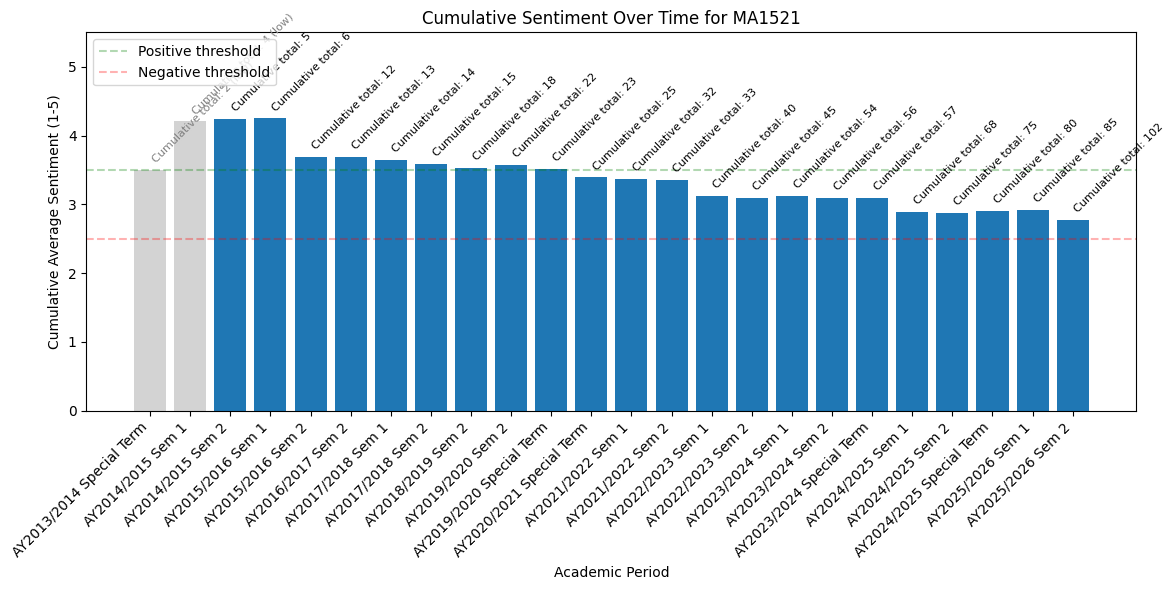

In [81]:
import matplotlib.pyplot as plt
import numpy as np

MIN_SAMPLES = 5 #remember that if number of comments below 5 we say insufficient reviews (comment for ethan)

def get_academic_period(date):
    month, year = date.month, date.year
    if month >= 8:
        return f"AY{year}/{year+1} Sem 1"
    elif month <= 5:
        return f"AY{year-1}/{year} Sem 2"
    else:
        return f"AY{year-1}/{year} Special Term"

def period_sort_key(period):
    term_order = {"Sem 1": 0, "Sem 2": 1, "Special Term": 2}
    ay_part, term = period.split(" ", 1)
    start_year = int(ay_part[2:6])
    return (start_year, term_order[term])

data_sorted = subset.copy()
data_sorted["date"] = pd.to_datetime(data_sorted["date"])
data_sorted = data_sorted.sort_values("date").reset_index(drop=True)
data_sorted["clean_message"] = data_sorted["message"].apply(clean_review_text)

if data_sorted.empty:
    print(f"No reviews found for {module}.")
else:
    pipeline_results = score_reviews(data_sorted["clean_message"].tolist(), truncation=True, max_length=512)

    all_scores = [get_score(res) for res in pipeline_results]

    data_sorted["sentiment_score"] = all_scores
    data_sorted["period"] = data_sorted["date"].apply(get_academic_period)

    #running cumulative count and mean, chronological order
    data_sorted["cum_n"]   = np.arange(1, len(data_sorted) + 1)
    data_sorted["cum_avg"] = data_sorted["sentiment_score"].expanding().mean()

    cum_summary = (
        data_sorted.groupby("period", sort=False)
        .agg(avg_sentiment=("cum_avg", "last"), n=("cum_n", "last"))
        .reset_index()
    )
    cum_summary["sort_key"] = cum_summary["period"].apply(period_sort_key)
    cum_summary = cum_summary.sort_values("sort_key").reset_index(drop=True)

    #code to plot the graph below (adjust if words overlap)
    colors = ["tab:blue" if n >= MIN_SAMPLES else "lightgray" for n in cum_summary["n"]]

    fig, ax1 = plt.subplots(figsize=(12, 6))
    bars = ax1.bar(cum_summary["period"], cum_summary["avg_sentiment"], color=colors)

    ax1.set_xlabel("Academic Period")
    ax1.set_ylabel("Cumulative Average Sentiment (1-5)")
    ax1.set_ylim(0, 5.5)
    ax1.axhline(y=3.5, color="green", linestyle="--", alpha=0.3, label="Positive threshold")
    ax1.axhline(y=2.5, color="red", linestyle="--", alpha=0.3, label="Negative threshold")

    for bar, n in zip(bars, cum_summary["n"]):
        label = f"Cumulative total: {n}" if n >= MIN_SAMPLES else f"Cumulative total: {n} (low)"
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
                  label, ha="left", va="bottom", fontsize=8, rotation=45,
                  color="black" if n >= MIN_SAMPLES else "gray")

    plt.xticks(rotation=45, ha="right")
    plt.title(f"Cumulative Sentiment Over Time for {module}")
    ax1.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    current_total = cum_summary["n"].iloc[-1]
    if current_total < MIN_SAMPLES:
        print(f"Cumulative review count is still below {MIN_SAMPLES} "
              f"(currently {current_total}). Sentiment score not yet reliable.")

##**Compare two modules side by side**

Enter module codes to compare, separated by commas (e.g., CS1010A, MA1521): cs1010a, ma1521

Analyzing sentiment for: CS1010A, MA1521...



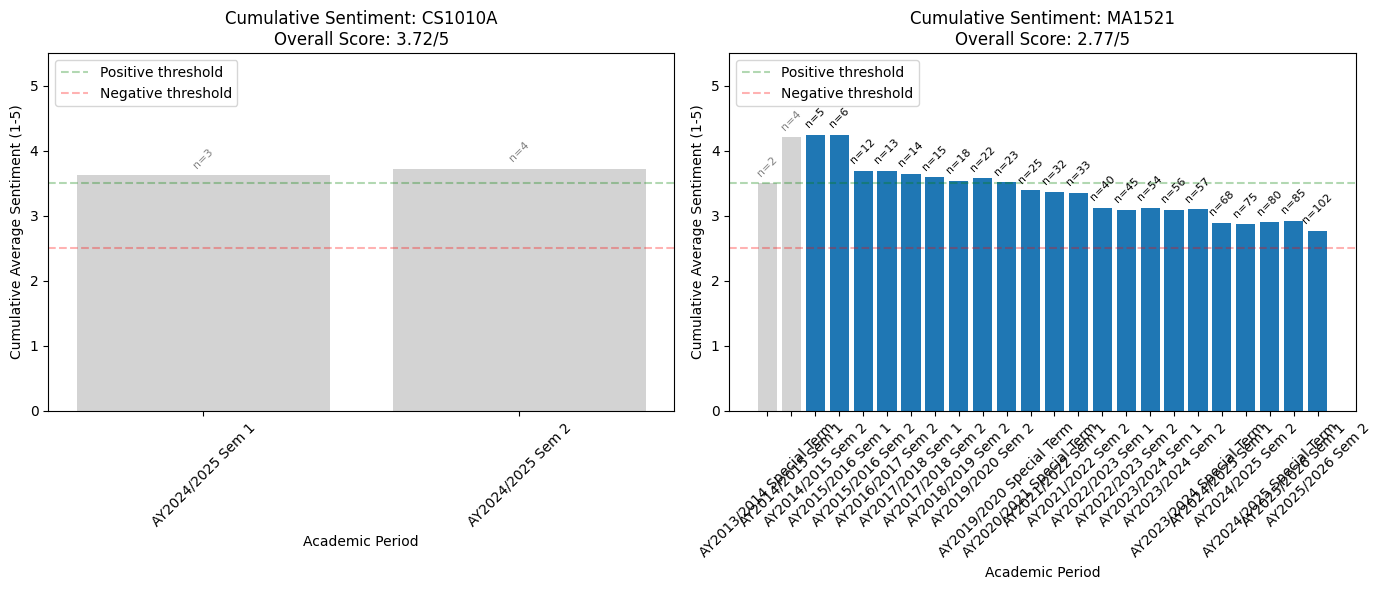

------------------------------------------------------------
MODULE COMPARISON SUMMARY
------------------------------------------------------------


,Module Code,Overall Sentiment,Review Count
0,CS1010A,3.72,4
1,MA1521,2.77,102


In [71]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

#Receive user input for multiple modules
input_str = input("Enter module codes to compare, separated by commas (e.g., CS1010A, MA1521): ")
modules_input = [m.upper().strip() for m in input_str.split(",")]

MIN_SAMPLES = 5
summary_data = []

num_modules = len(modules_input)
fig, axes = plt.subplots(1, num_modules, figsize=(7 * num_modules, 6), squeeze=False)
axes = axes.flatten()

print(f"\nAnalyzing sentiment for: {', '.join(modules_input)}...\n")

for idx, module in enumerate(modules_input):
    subset = df_reviews[df_reviews["module_code"] == module]
    ax = axes[idx]

    if subset.empty:
        ax.set_title(f"No reviews found for {module}")
        ax.axis('off')
        summary_data.append({"Module Code": module, "Overall Sentiment": "N/A", "Review Count": 0})
        continue

    #Clean messages and run predictions
    data_sorted = subset.copy()
    data_sorted["date"] = pd.to_datetime(data_sorted["date"])
    data_sorted = data_sorted.sort_values("date").reset_index(drop=True)

    data_sorted["clean_message"] = data_sorted["message"].apply(clean_review_text)

    pipeline_results = score_reviews(data_sorted["clean_message"].tolist(), truncation=True, max_length=512)
    all_scores = [get_score(res) for res in pipeline_results]

    data_sorted["sentiment_score"] = all_scores
    data_sorted["period"] = data_sorted["date"].apply(get_academic_period)

    data_sorted["cum_n"] = np.arange(1, len(data_sorted) + 1)
    data_sorted["cum_avg"] = data_sorted["sentiment_score"].expanding().mean()

    overall_avg = round(sum(all_scores) / len(all_scores), 2)
    summary_data.append({"Module Code": module, "Overall Sentiment": overall_avg, "Review Count": len(all_scores)})

    cum_summary = (
        data_sorted.groupby("period", sort=False)
        .agg(avg_sentiment=("cum_avg", "last"), n=("cum_n", "last"))
        .reset_index()
    )
    cum_summary["sort_key"] = cum_summary["period"].apply(period_sort_key)
    cum_summary = cum_summary.sort_values("sort_key").reset_index(drop=True)

    colors = ["tab:blue" if n >= MIN_SAMPLES else "lightgray" for n in cum_summary["n"]]
    bars = ax.bar(cum_summary["period"], cum_summary["avg_sentiment"], color=colors)

    ax.set_xlabel("Academic Period")
    ax.set_ylabel("Cumulative Average Sentiment (1-5)")
    ax.set_ylim(0, 5.5)
    ax.axhline(y=3.5, color="green", linestyle="--", alpha=0.3, label="Positive threshold")
    ax.axhline(y=2.5, color="red", linestyle="--", alpha=0.3, label="Negative threshold")

    for bar, n in zip(bars, cum_summary["n"]):
        label = f"n={n}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
                label, ha="center", va="bottom", fontsize=8, rotation=45,
                color="black" if n >= MIN_SAMPLES else "gray")

    ax.set_title(f"Cumulative Sentiment: {module}\nOverall Score: {overall_avg}/5")
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

print("-" * 60)
print("MODULE COMPARISON SUMMARY")
print("-" * 60)
summary_df = pd.DataFrame(summary_data)
display(summary_df)